In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


In [2]:
def first_zero_crossing(da):
    """
    Return the first time where the data crosses zero, ignoring NaNs.
    """
    valid = da.notnull()
    da = da.where(valid, drop=True)

    values = da.values

    idx = np.where(np.diff(np.sign(values)) != 0)[0]

    if len(idx) == 0:
        return None

    return da.time[idx[0] + 1]

def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['gC/m^2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'dissic' and stat == 'integral' and vert_stat == 'integral' and da.units in ['mol m-3 x m x m2']:
        converter = 12.0107 /1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
        
    elif varia == 'co2mass' and stat is None and vert_stat is None and da.units in ['kg']:
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'co2mass' and stat == 'integral' and vert_stat is None and da.units in ['kg CO2/m2 x m2']:   # this case corresponds to NASA-GISS
        converter = 12.0107 / 44.011 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
        
    elif varia == 'fco2antt' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s','kg s-1 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and vert_stat is None and da.units in ['gC/m^2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'fgco2' and stat == 'integral' and vert_stat is None and da.units in ['mmol/m^3 cm/s x m2 x s']:
        converter = 10**-5 * 12.0107/ 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da

    return da_conv

def get_stat(varia,model):

    # default settings
    if varia in ['tas','tos']:
        stat = 'mean'
    elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt']:
        stat = 'integral'
    elif varia in ['co2mass']:
        stat = None

    # overwrite some choices
    if model == 'GISSE2.1-G-CC2':
        if varia == 'co2mass':
            stat = 'integral'
    
    return stat


def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat
    
def get_infix(varia,default=True):
    infix_base = 'vertical_'
    if default == True:
        if varia in ['dissic']:
            infix = infix_base+'integral_'
        else:
            infix = ''
    else:
        infix = ''
    return infix    

def get_suffix(varia,default=True):
    if default == True:
        if varia in ['fco2antt','fgco2','nbp']:
            suffix = '_cumulated'
        else:
            suffix = ''
    else:
        suffix = ''
    return suffix    

In [3]:
varias = ['tas']#,'fgco2','nbp','co2mass','fco2antt']#,'dissic','cLand'] # ,'cLand','dissic'.  # 'tas','tos',
models = ['ACCESS-ESM1-5','MIROC-ES2L','GFDL-ESM2M','IPSL-CM6-ESMCO2','NorESM2-LM','GISSE2.1-G-CC2','EC-Earth3-ESM-1','CESM2','UKESM1-2']#]#,'IPSL-CM6-ESMCO2']#,'GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1']#['GISSE2.1-G-CC2'].   #]#, ]#, # 
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1
root_dir = f'./../01_postprocessed_data/global_time_series'

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'monthly'#'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

In [4]:
def get_reference_value(varia,model):
    freq_input = get_freq_input(model)
    stat = get_stat(varia,model)
    vert_stat = get_vert_stat(varia,default=True)
    mgrab = MODELgrabber.get_grabber(model)
    if model == 'GISSE2.1-G-CC2':
        member = mgrab.get_member(run)
    else:
        member = mgrab.get_member()
    infix = get_infix(varia,default=True)
    suffix = get_suffix(varia,default=True)
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'

    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    
    if varia == 'tas':
        annual_stat = global_stat.resample(time="1YS").mean()
    else:
        annual_stat = global_stat.resample(time="1YS").first()

    if model == 'ACCESS-ESM1-5':
        reference_value = annual_stat.sel(time=f'{ref_year+170:04d}-01-01').values
    else:
        try:
            reference_value = annual_stat.sel(time=f'{ref_year:04d}-01-01').values
        except:
            reference_value = annual_stat.sel(time=f'{ref_year+1:04d}-01-01').values



    return reference_value


running_mean_years = 11

all_annual_stats = dict()
for varia in varias:
    all_annual_stats[varia] = dict()
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia,model)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        if model == 'GISSE2.1-G-CC2':
            member = mgrab.get_member(run)
        else:
            member = mgrab.get_member()
        infix = get_infix(varia,default=True)
        suffix = get_suffix(varia,default=True)
        #print(varia,model)
        #print(varia,model,reference_value)
        #color = model_dict[model].color_id
        annual_stats = dict()
        for run in runs:
            try:
                reference_value = get_reference_value(varia,model)
                #print(reference_value)
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}{suffix}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}{suffix}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}{suffix}"]
                global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
                #print(global_stat.values)
                #print(global_stat.time)
    
                if varia == 'tas':
                    annual_stat = global_stat.resample(time="1YS").mean()
                else:
                    annual_stat = global_stat.resample(time="1YS").last()
    
                #if varia == 'co2mass':
                #    offsetter = get_offset_value(varia,model,reference_value)
                #    annual_stat = annual_stat + offsetter
    
                # correct for reference value
                annual_stat = annual_stat - reference_value
                
                annual_stat.attrs['units'] = global_stat.units
                
                # convert
                annual_stat = convert_units(varia,stat,annual_stat)
    
                # get the start and end
                time_slice = TimeOperator.get_time_start_and_end(model,run,model_dict,ref_year=ref_year)
                annual_stat = annual_stat.sel(time=time_slice)
                
                
                # if model == 'GISS' and variable is fco2antt, divide multiply with 12.0107 / 44.011 (is erroneously reported as kgCO2/m2/s instead of kgC/m2/s)
                if model == 'GISSE2.1-G-CC2':
                    if varia == 'fco2antt':
                        annual_stat = annual_stat * 12/44 # 12.0107/44.011

                #if varia == 'tas':
                #    annual_stat = annual_stat.rolling(time=running_mean_years,center=True,min_periods=1).mean()
                
                # put into dictionary
                annual_stats[run] = annual_stat

            except:
                print(f'Nothing to do for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        all_annual_stats[varia][model] = annual_stats    

None
0198-12-31 00:00:00
0160-12-31 00:00:00
0248-12-31 00:00:00
None
None
None
None
0231-12-31 00:00:00
0166-12-31 00:00:00
0281-12-31 00:00:00
None
None
None
None
0220-12-31 00:00:00
0164-12-31 00:00:00
0270-12-31 00:00:00
None
None
None
None
0249-12-31 00:00:00
0176-12-31 00:00:00
0299-12-31 00:00:00
None
None
None
None
0224-12-31 00:00:00
0168-12-31 00:00:00
0274-12-31 00:00:00
None
None
None
working on server spirit
Nothing to do for tas, GISSE2.1-G-CC2, r1i1p1f1, esm-piControl, monthly, global mean.
Nothing to do for tas, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0, monthly, global mean.
Nothing to do for tas, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global mean.
Nothing to do for tas, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global mean.
Nothing to do for tas, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global mean.
Nothing to do for tas, GISSE2.1-G-CC2, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global mean.
Nothing to do for tas, GISSE2.1

## Now get the vertical profiles

In [13]:
root_root = '/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle'
#root_root = '/home/b/b384080/TIPMIP_carbon_cycle'#/01_postprocessed_data/vertical_profiles'
outroot = f'{root_root}/01_postprocessed_data/vertical_profiles'

#member = '001'
freq_input = 'monthly'
stat = 'integral'
model = 'IPSL-CM6-ESMCO2'#'GFDL-ESM2M'#'CESM2' #'NorESM2-LM'#'EC-Earth3-ESM-1' #'IPSL-CM6-ESMCO2'#'GISSE2.1-G-CC2' # 'EC-Earth3-ESM-1' #'GFDL-ESM2M'#''NorESM2-LM'#'CESM2'#'IPSL-CM6-ESMCO2'#'GFDL-ESM2M'#'CESM2'#'IPSL-CM6-ESMCO2'#'GFDL-ESM2M'#
mgrab = MODELgrabber.get_grabber(model)

varia = 'dissic'#'so'#'o2'#'dissic'#'dissic'#'thetao'##'o2'
ref_year = 1

if model == 'CESM2':
    member = '001'
elif model == 'NorESM2-LM':
    member = 'r1i1p1f1'
elif model == 'IPSL-CM6-ESMCO2':
    member = 'r1i2p3f1'
elif model == 'GFDL-ESM2M':
    member = 'r1i1p1f1'
elif model == 'GISSE2.1-G-CC2':
    member = 'r1i1p1f3'
elif model == 'EC-Earth3-ESM-1':
    member = 'r1i1p1f1'

if varia == 'thetao':
    unit = "°C"
    vmin = -4
    vmax = 4
    cmap = 'cmo.balance'
elif varia == 'dissic':
    unit = r'mmol m$^{-3}$'
    vmin = -260
    vmax = 260
    cmap = 'cmo.balance_r'
elif varia == 'o2':
    unit = r'mmol m$^{-3}$'
    vmin = -40
    vmax = 40
    cmap = 'BrBG'
elif varia == 'so':
    unit = r'- or g/kg'
    vmin = -.4
    vmax = .4
    cmap = 'cmo.curl'
elif varia == 'no3':
    unit = r'mmol m-3'
    vmin = -3
    vmax = 3
    cmap = 'cmo.curl_r'

runs = ['esm-piControl','esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0']
#runs = ['esm-up2p0','esm-up2p0-gwl2p0','esm-up2p0-gwl4p0','esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0']
#runs = ['esm-piControl','esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0']

dd = dict()
for rdx,run in enumerate(runs):
    save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
    save_string = f'{varia}_{model}_{run}_{member}_global_{stat}.nc'
    dd[run] = xr.open_dataset(f'{save_dir}/{save_string}',use_cftime=True) #* 1000. #.groupby('time.year').mean('time')
    if stat == 'mean':
        if varia == 'dissic' and dd[run][f'{varia}_global_{stat}'].attrs['units'] == 'mol m-3': # see NorESM2-LM
            dd[run] = dd[run]*1000.
        if varia == 'o2' and dd[run][f'{varia}_global_{stat}'].attrs['units'] == 'mol m-3': # see NorESM2-LM
            dd[run] = dd[run]*1000.
        if varia == 'no3' and dd[run][f'{varia}_global_{stat}'].attrs['units'] == 'mol m-3': # see NorESM2-LM
            dd[run] = dd[run]*1000.
        if varia == 'so' and dd[run][f'{varia}_global_{stat}'].attrs['units'] == '0.001' and model not in ['IPSL-CM6-ESMCO2','EC-Earth3-ESM-1']: # see NorESM2-LM
            dd[run] = dd[run]*1000.
    elif stat == 'integral':
        if varia == 'dissic' and dd[run][f'{varia}_global_{stat}'].attrs['units'] == 'mol m-3 x m2': # see NorESM2-LM
            dd[run] = dd[run]*12.0107/1000/1000/1000/1000/1000. # PgC 
            dd[run][f'{varia}_global_{stat}'].attrs['units'] = 'PgC'
    dd[run] = TimeOperator.shift_time_axis_to_ref_year(model, dd[run],ref_year=ref_year,set_to_start_of_months=True)

dz = mgrab.get_dz(varia,'esm-piControl',freq_input=freq_input,verbose_level=0)

troot = f'{root_root}/01_postprocessed_data/global_time_series'
taria = 'tas'
dt = dict()
for rdx,run in enumerate(runs):
    tave_dir = f'{troot}/{taria}/{model}/{run}/{member}/{freq_input}/global_mean'
    tave_string = f'{taria}_{model}_{run}_{member}_global_mean.nc'
    dt[run] = xr.open_dataset(f'{tave_dir}/{tave_string}',use_cftime=True)#.groupby('time.year').mean('time')
    dt[run] = TimeOperator.shift_time_axis_to_ref_year(model, dt[run],ref_year=ref_year,set_to_start_of_months=True)


/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v*/dissic*_gn_*.nc
['/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gn_180001-184909.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gn_185001-194912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gn_195001-204912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gn_205001-214912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gn_215001-224912.nc', '/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESM

In [14]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['dissic']#['tas','tos','fgco2','nbp','intpp','npp','cSoil','intdic']#'cLand','cVeg'['tos','fgco2','intpp','intdic','tas','cLand','cSoil','cVeg','npp','nbp']#['intdic']#['dissic']#['tos','fgco2','intpp','intdic'] #['cLand','cSoil','cVeg','npp','nbp'] #['tas']#['tos','fgco2','intpp','intdic'] #['cLand','cSoil','cVeg','npp','nbp'] #['tas']#['tos','fgco2','intpp','intdic'] #[,'tas'] #['intdic']#['cLand','cSoil','cVeg','tos','nbp','fgco2','npp','intpp','tas']#'dissic'] #['tas']#['dissic']##['cVeg']#'tas','tos', #['tas','tos', #'tas', #['npp']#['cSoilFast','cSoilMedium','cSoilSlow']#['epc100','cLand','cVeg','nbp','intpp','npp']#,'fgco2',''epc100']#['epc100','fgco2','intpp','tos']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM']#['GISSE2.1-G-CC2']#['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['CESM2']#['UKESM1-2']#['EC-Earth3-ESM-1'] #['UKESM1-2']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#[]#['ACCESS-ESM1-5']#['CESM2']#['MIROC-ES2L']#['ACCESS-ESM1-5']#['UKESM1-2']#['EC-Earth3-ESM-1'] #['NorESM2-LM']#['GISSE2.1-G-CC2']#['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['NorESM2-LM']##['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['CESM2']#['ACCESS-ESM1-5'] #['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M']#['MIROC-ES2L'] ['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['UKESM1-2']#['IPSL-CM6-ESMCO2']#['IPSL-CM6-ESMCO2']#[]#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')#[1:]#:1]#[5:]#[1:]#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

stat = 'integral'

# choose the type of temporal statisic
temporal_stats = ['mean'] # 'std', 'linear trend', 
# choose the time window length (in years) for rolling_mean
rm_window = 31 # in years
# choose the time_window_size for tim slices
time_window_size = 21 # in years
# choose the reference 
reference = 'first_year_of_rampup' # 'first_year_of_piC', 'first_10y_of_rampup', ...
# choose GMST levels at which to calculate time slice maps (for rampup and rampdown). For the piC, and stabilizations, I calculate the time slice statistic over the first time_window_size years
#gmst_levels = [0,1,2,3,4]

#server='spirit' # 'cineca'#
outroot = './../01_postprocessed_data/vertical_profiles/'

# Define the time slice names
time_slice_names = ['piC_at_start',
                    'rampup_1K',
                    'rampup_2K',
                    'rampup_3K',
                    'rampup_4K',
        
                    'stab2K',
                    'stab4K',
        
                    'rampdn2K_1K',
                    'rampdn2K_0K',
        
                    'rampdn4K_3K',
                    'rampdn4K_2K',     
                    'rampdn4K_1K',
                    'rampdn4K_0K',             
        
                    'restab2K'
                   ]

def identify_run(time_slice_name):
    if 'rampup' in time_slice_name:
        run = 'esm-up2p0'
    elif 'piC' in time_slice_name:
        run = 'esm-piControl'
    elif time_slice_name == 'stab2K':
        run = 'esm-up2p0-gwl2p0'
    elif time_slice_name == 'stab4K':
        run = 'esm-up2p0-gwl4p0'        
    elif 'rampdn2K' in time_slice_name:
        run = 'esm-up2p0-gwl2p0-50y-dn2p0'
    elif 'rampdn4K' in time_slice_name:
        run = 'esm-up2p0-gwl4p0-50y-dn2p0'
    elif time_slice_name == 'restab2K':
        run = 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0' 
    return run


def get_time_range_underlying_time_slice(model,time_slice_name,reference,time_window_size,rm_window,centered_running_mean=True):    #,running_mean_years=31,centered_running_mean=True,reference_slice='jones2025'):

    # get the global mean surface temperature
    varia = 'tas'
    run = identify_run(time_slice_name)

    # get the model_dict for extra info
    model_dict = pmods.get_model_dict('all')
    
    # Decide what to do
    if '_0K' in time_slice_name or '_1K' in time_slice_name or '_2K' in time_slice_name or '_3K' in time_slice_name or '_4K' in time_slice_name:
        print('    ... need to identify the time range')
        need_to_identify = True
    elif 'stab' in time_slice_name or time_slice_name == 'piC_at_start':
        print('    ... no need to identify anything - already clearly defined')
        need_to_identify = False
    
    # If there is a need to identify:
    if need_to_identify:

        # Handle the reference data
        if reference == 'first_year_of_rampup':
            reference_run = 'esm-up2p0'
        elif reference == 'first_year_of_piC':
            reference_run = 'esm-piControl'
            
        # get the reference data
        print(f'    ... loading in the GMST data for the reference run {reference_run}.')
        ref_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{reference_run}/{member}/{freq_input}/global_mean'
        ref_str = f'{ref_dir}/{varia}_{model}_{reference_run}_{member}_global_mean.nc'
        print(f'    ... loading reference: {ref_str}')
        with xr.open_dataset(ref_str,use_cftime=True) as ref_ds:
            if 'first_year' in reference:
                ref_ds = TimeOperator.shift_time_axis_by_n_years(ref_ds,n=0)
                ref_ds_annual = ref_ds.resample(time='1YS').mean()
                t0 = cftime.DatetimeProlepticGregorian(model_dict[model].rampup_start_year,1,1)
                ref_val = ref_ds_annual[f'{varia}_global_mean'].sel(time=t0).values 
            #print(ref_val)
        
        # Handle the run data
        print(f'    ... loading in the GMST data for the run {run}.')
        run_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/global_mean'
        run_str = f'{run_dir}/{varia}_{model}_{run}_{member}_global_mean.nc'
        print(f'    ... loading run: {run_str}')
        with xr.open_dataset(run_str,use_cftime=True) as run_ds:
            if 'first_year' in reference:
                run_ds_annual = run_ds.resample(time='1YS').mean()
                run_ds_annual_anom = run_ds_annual[f'{varia}_global_mean'] - ref_val

                # do a rolling_mean
                run_ds_annual_anom_rm = run_ds_annual_anom.rolling(time=rm_window,center=centered_running_mean,min_periods=1).mean(dim='time')
                
                # get the GWL level
                GWL = int(time_slice_name.split('_')[-1][0])
                print(f'    ... GWL = {GWL}K')
                
                # masks
                if run == 'esm-up2p0':
                    mask_bool = run_ds_annual_anom_rm > GWL                    
                elif run in ['esm-up2p0-gwl2p0-50y-dn2p0','esm-up2p0-gwl4p0-50y-dn2p0']:
                    mask_bool = run_ds_annual_anom_rm < GWL                    

                
                if mask_bool.any(dim="time"):
                    first_idx = mask_bool.argmax(dim="time")
                    first_time = run_ds_annual_anom_rm.time.isel(time=first_idx)
                    first_year = int(first_time.dt.year.values)
        
                    print(
                        f'    ... first crossing at anomaly of '
                        f'{run_ds_annual_anom_rm.isel(time=first_idx).values}K'
                    )
                    
                    time_slice_start_year = int(first_year - (time_window_size-1)/2)
                    time_slice_end_year = int(first_year + (time_window_size-1)/2)
                else:
                    first_year = np.nan
                    time_slice_start_year = np.nan
                    time_slice_end_year = np.nan               


    else:
        print(f'    ... no need for any reference run.')
        if time_slice_name == 'piC_at_start':
            if model == 'ACCESS-ESM1-5':
                time_slice_start_year = 271 #model_dict[model].rampup_start_year
                time_slice_end_year = 271+time_window_size-1 #model_dict[model].rampup_start_year+time_window_size-1 
            else:
                time_slice_start_year = model_dict[model].rampup_start_year
                time_slice_end_year = model_dict[model].rampup_start_year+time_window_size-1 
        elif time_slice_name == 'stab2K':
            time_slice_start_year = model_dict[model].stab2K_start_year
            time_slice_end_year = model_dict[model].stab2K_start_year+50 - time_window_size+1 #  last (time_window_size)years of the stabilization before rampdown
        elif time_slice_name == 'stab4K':
            time_slice_start_year = model_dict[model].stab4K_start_year
            time_slice_end_year = model_dict[model].stab4K_start_year+50 - time_window_size+1 #  last (time_window_size)years of the stabilization before rampdown
        elif time_slice_name == 'restab2K':
            time_slice_start_year = model_dict[model].restab2K_start_year
            time_slice_end_year = model_dict[model].restab2K_start_year+50 - time_window_size+1  #  last (time_window_size)years of the restabilization

    # turn nan years into None
    print(time_slice_start_year)
    print(time_slice_end_year)
    if np.isnan(time_slice_start_year):
        time_slice_start_year = None
    if np.isnan(time_slice_end_year):
        time_slice_end_year = None
    print(time_slice_start_year)
    print(time_slice_end_year)
    
    return time_slice_start_year, time_slice_end_year


def calc_time_slice_stat(varia,model,time_slice_name,time_slice_start_year,time_slice_end_year,temporal_stat='mean'):

    if model == 'CESM2':
        print(varia)
        varia = mgrab.varia_mapper_cmor_to_model(varia)
        print(varia)
                
    # first get the dataset
    #da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=0)#,server=server)#,server=server)
    save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_integral'
    save_string = f'{varia}_{model}_{run}_{member}_global_integral.nc'
    da = xr.open_dataset(f'{save_dir}/{save_string}',use_cftime=True) #* 1000. #.groupby('time.year').mean('time')
    
    print(f'... loading {da.time.size} data points in time.')

    if model == 'CESM2' and varia == 'TEMP':
        print('choosing only the shallowest layer')
        da = da.isel(z_t=0)#.squeeze().persist()
        print(da)

    # make sure the time dimension is Proleptic Gregorian
    da = TimeOperator.shift_time_axis_by_n_years(da,n=0)
    
    # get unit
    #unit = da.units

    # resample to annual means
    da_annual = da.resample(time='1YS').mean(dim='time') # weight with month lengths?
    #print(da_annual.time)

    if time_slice_start_year is None or time_slice_end_year is None:
    
        da_annual_slice = xr.full_like(
            da_annual.isel(time=slice(0, 2)).astype(float),
            np.nan,
        )
    
    else:
        da_annual_slice = da_annual.sel(
            time=slice(
                cftime.DatetimeProlepticGregorian(time_slice_start_year, 1, 1),
                cftime.DatetimeProlepticGregorian(time_slice_end_year, 1, 1),
            )
        )

    if temporal_stat == 'mean':
        temp_statistic = da_annual_slice.mean(dim='time')
        #unit = unit
    else:
        raise Exception('This temporal_stat is not yet defined.')

    print(temp_statistic)
    
    return temp_statistic#, unit
    

In [15]:
sdict = dict()
dzdict = dict()

for varia in varias:
    sdict[varia] = dict()
    dzdict[varia] = dict()
    vert_stat = get_vert_stat(varia)
    for model in models:
        sdict[varia][model] = dict()
        dzdict[varia][model] = dict()
        mgrab = MODELgrabber.get_grabber(model)
        #stat = get_stat(varia,model)
        
        print(f'---{model}---')
        temporal_stat_dict = dict()
        for time_slice_name in time_slice_names:
            sdict[varia][model][time_slice_name] = dict()
            dzdict[varia][model][time_slice_name] = dict()
            #if time_slice_name == 'restab2K' and model in ['GISSE2.1-G-CC2','EC-Earth3-ESM-1']:
            #    continue

            # identify the run for the time slice statistic
            run = identify_run(time_slice_name)
            if model == 'GISSE2.1-G-CC2':
                member = mgrab.get_member(run)
            else:
                member = mgrab.get_member()

            
            print(f'-> calculate time slice statistic(s) for {varia}, {model}, {time_slice_name}: in {run}.')

            print('... identify the time range over which I want to calculate the time slice.')
            time_slice_start_year, time_slice_end_year = get_time_range_underlying_time_slice(model,time_slice_name,reference,time_window_size,rm_window,centered_running_mean=True)
            print('... the time range for the time slice statistic is going to be:',time_slice_start_year, time_slice_end_year)

            print('... compute the statisic(s)')
            for temporal_stat in temporal_stats:

                print(f'    ... computing the {temporal_stat}...')
                statistic = calc_time_slice_stat(varia,model,time_slice_name,time_slice_start_year,time_slice_end_year,temporal_stat=temporal_stat)
                dz = mgrab.get_dz(varia,run,freq_input=freq_input,verbose_level=0)

                sdict[varia][model][time_slice_name][temporal_stat] = statistic
                dzdict[varia][model][time_slice_name][temporal_stat] = dz

---IPSL-CM6-ESMCO2---
-> calculate time slice statistic(s) for dissic, IPSL-CM6-ESMCO2, piC_at_start: in esm-piControl.
... identify the time range over which I want to calculate the time slice.
    ... no need to identify anything - already clearly defined
    ... no need for any reference run.
1850
1870
1850
1870
... the time range for the time slice statistic is going to be: 1850 1870
... compute the statisic(s)
    ... computing the mean...
... loading 7788 data points in time.
<xarray.Dataset>
Dimensions:                 (lev: 75)
Coordinates:
  * lev                     (lev) float64 0.5058 1.556 ... 5.698e+03 5.902e+03
Data variables:
    dissic_global_integral  (lev) float32 7.346e+14 7.743e+14 ... 7.759e+15 0.0
/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v*/dissic*_gn_*.nc
['/projets/TipESM/IPSL/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/Omon/dissic/gn/v20260318/dissic_Omon_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_gn_180001-184909.nc', '/projets/TipESM

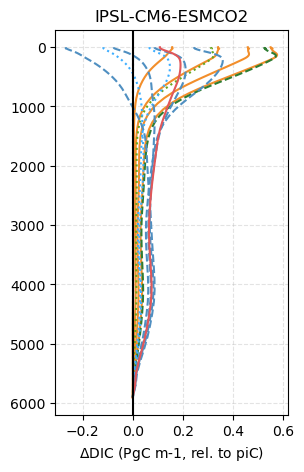

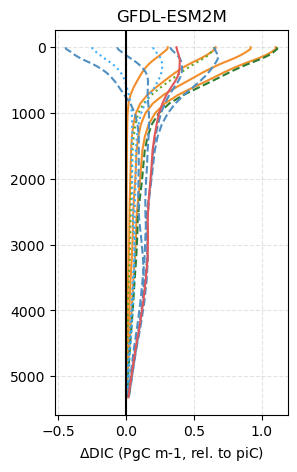

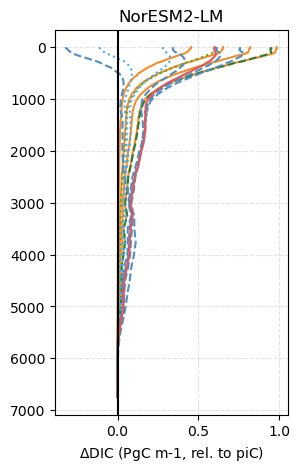

In [16]:
for model in models:
    if model == 'GFDL-ESM2M':
        zlev = 'olevel'
    else:
        zlev = 'lev'
    
    ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
    fig, ax = plt.subplots(figsize=(3,5))
    for time_slice_name in time_slice_names:
        profile = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral / dzdict['dissic'][model][time_slice_name]['mean']
        profile = profile * 12.0107/1000/1000/1000/1000/1000
        run = identify_run(time_slice_name)
        ax.plot(profile,profile[zlev],color=run_dict[run].color_id,linestyle=run_dict[run].linestyle_id)
    ax.grid(alpha=0.35,linestyle='--',zorder=-10)
    ax.set_title(model)
    ax.axvline(0,color='k')
    ax.invert_yaxis()
    ax.set_xlabel(f'$\Delta$DIC (PgC m-1, rel. to piC)')

## Do the CDF (conversion and dz is actually not needed, see two cells below...)

[0.]
[538701.87759269]
[516587.60899292]
[501353.11636221]
[489214.55380417]
[506373.74495579]
[484528.23306587]
[434395.33386462]
[281710.37160485]
[443596.09589037]
[405759.83804588]
[333842.83863351]
[102108.07344426]
[398771.09812352]
[0.]
[503104.03097647]
[478907.89515028]
[463734.49594211]
[453469.02379876]
[470138.899681]
[448722.22553023]
[403330.93128925]
[166163.71686937]
[404874.87230268]
[375596.53311367]
[317655.78967745]
[117259.61013423]
[372364.98699808]
[0.]
[744125.6329388]
[723178.33043009]
[710095.90940526]
[700432.77333405]
[717047.28191341]
[698195.57393106]
[669000.46846962]
[558991.48462517]
[676148.48084156]
[662779.36960874]
[633250.24185537]
[348285.39229547]
[655966.02896629]


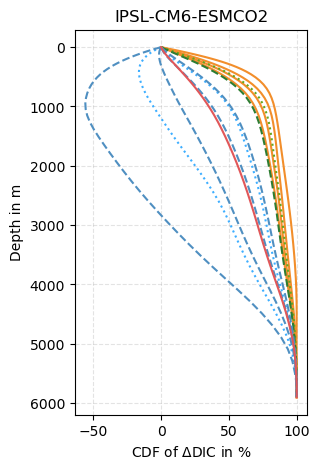

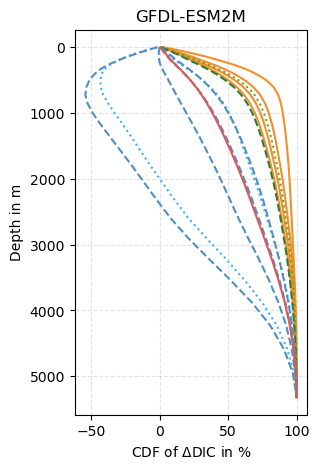

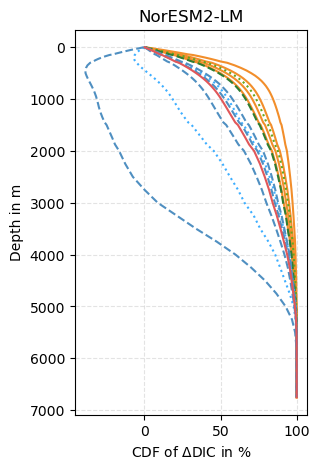

In [17]:
for model in models:
    if model == 'GFDL-ESM2M':
        zlev = 'olevel'
    else:
        zlev = 'lev'
    
    ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
    fig, ax = plt.subplots(figsize=(3,5))
    for time_slice_name in time_slice_names:
        vals = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral
        dz = dzdict['dissic'][model][time_slice_name]['mean']
        profile = vals / dz
        profile = profile * 12.0107/1000/1000/1000/1000/1000
        profile = (profile*dz).cumsum(zlev)/(profile*dz).sum(zlev)*100
        print((profile*dz).sum(zlev).values)
        run = identify_run(time_slice_name)
        ax.plot(profile,profile[zlev],color=run_dict[run].color_id,linestyle=run_dict[run].linestyle_id)
    ax.grid(alpha=0.35,linestyle='--',zorder=-10)
    ax.set_title(model)
    ax.invert_yaxis()
    ax.set_ylabel('Depth in m')
    ax.set_xlabel(f'CDF of $\Delta$DIC in %')

0.0
4085.8298
3759.1023
3563.649
3408.7395
3611.5503
3343.049
2759.119
1178.9874
2855.4705
2473.7854
1805.2042
-348.11353
2428.7124
0.0
2897.7913
2493.7092
2314.9128
2203.272
2374.78
2148.6667
1694.394
-337.5647
1728.2155
1488.2556
1034.3738
-555.1129
1486.0399
0.0
4679.9883
4318.819
4112.6406
3972.4727
4210.468
3935.2297
3491.2083
2061.1035
3605.7827
3425.2273
3057.44
-36.109802
3352.6826


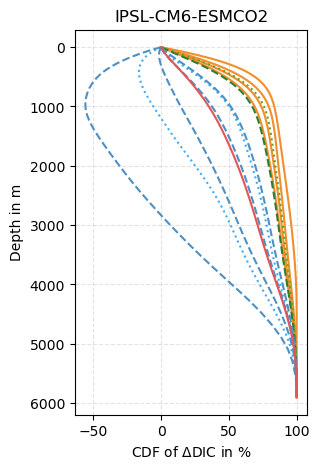

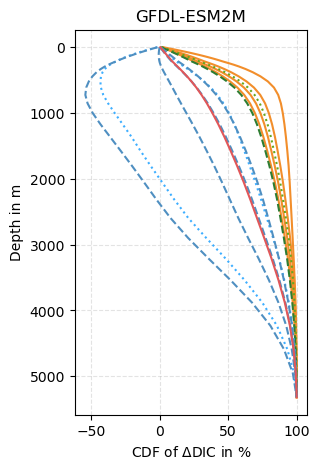

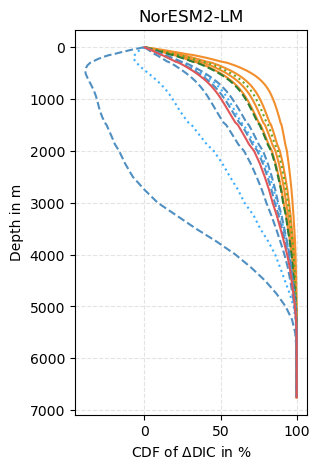

In [18]:
for model in models:
    if model == 'GFDL-ESM2M':
        zlev = 'olevel'
    else:
        zlev = 'lev'
        
    ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
    fig, ax = plt.subplots(figsize=(3,5))
    for time_slice_name in time_slice_names:
        vals = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral
        profile = vals
        profile = (profile).cumsum(zlev)/(profile).sum(zlev)*100
        print((profile).sum(zlev).values)
        run = identify_run(time_slice_name)
        ax.plot(profile,profile[zlev],color=run_dict[run].color_id,linestyle=run_dict[run].linestyle_id)
    ax.grid(alpha=0.35,linestyle='--',zorder=-10)
    ax.set_title(model)
    ax.invert_yaxis()
    ax.set_ylabel('Depth in m')
    ax.set_xlabel(f'CDF of $\Delta$DIC in %')

Text(0, 0.5, 'Depth in m')

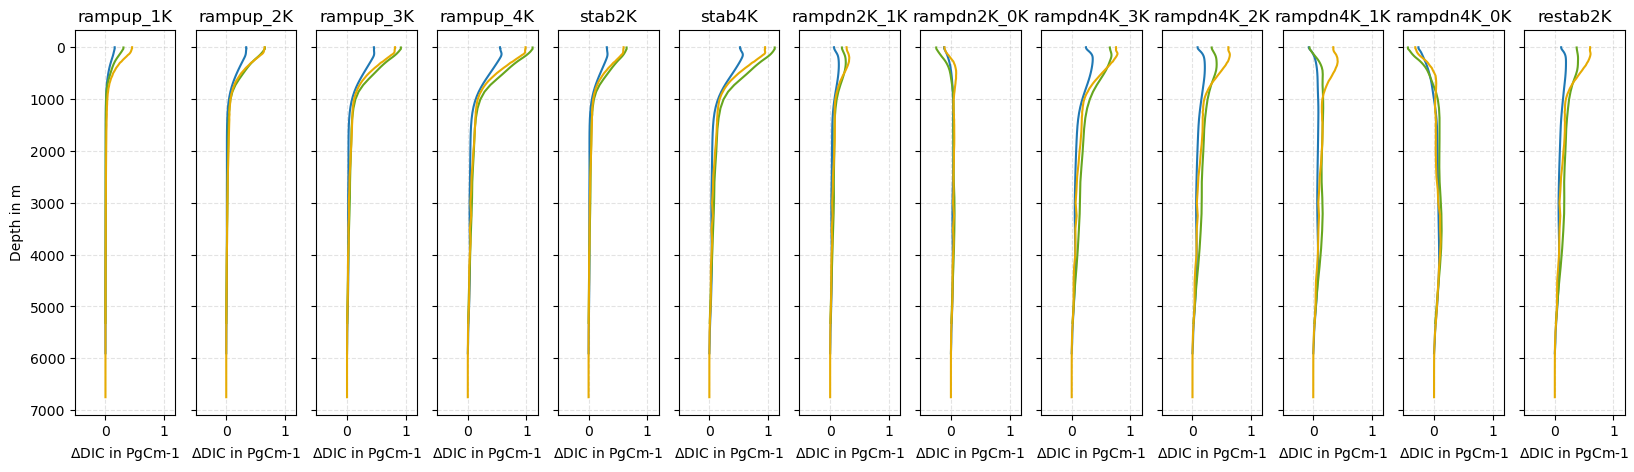

In [34]:
fig, ax = plt.subplots(1,len(time_slice_names)-1,figsize=(20,5),sharey=True,sharex=True)
for tdx,time_slice_name in enumerate(time_slice_names[1:]):

    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
        profile = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral / dzdict['dissic'][model][time_slice_name]['mean']
        profile = profile * 12.0107/1000/1000/1000/1000/1000
        run = identify_run(time_slice_name)
        ax[tdx].plot(profile,profile[zlev],color=model_dict[model].color_id)#,linestyle=model_dict[model].linestyle_id)
        
    ax[tdx].grid(alpha=0.35,linestyle='--',zorder=-10)
    ax[tdx].set_title(time_slice_name)
    ax[tdx].set_xlabel(f'$\Delta$DIC in PgCm-1')

ax[0].invert_yaxis()
ax[0].set_ylabel('Depth in m')


Text(0, 0.5, 'Depth in m')

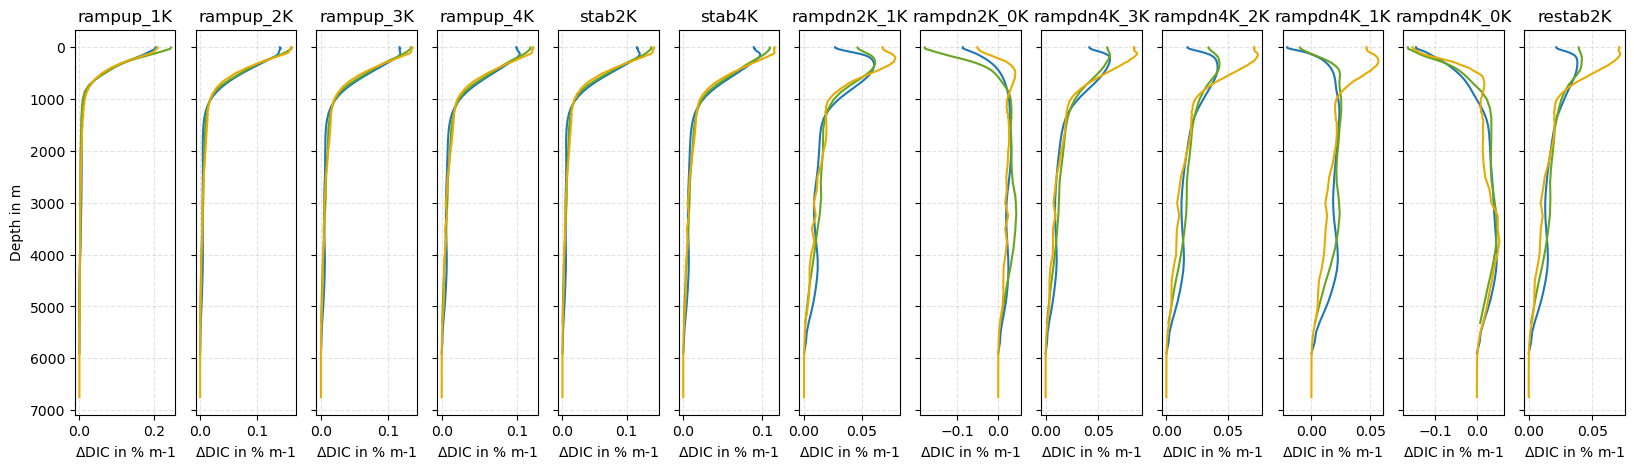

In [38]:
fig, ax = plt.subplots(1,len(time_slice_names)-1,figsize=(20,5),sharey=True)#,sharex=True)
for tdx,time_slice_name in enumerate(time_slice_names[1:]):

    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
        dz = dzdict['dissic'][model][time_slice_name]['mean']
        profile = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral / dz
        profile = profile * 12.0107/1000/1000/1000/1000/1000
        profile_sum = (profile*dz).sum(zlev)
        #print(profile_sum.values)
        profile = profile/profile_sum*100
        run = identify_run(time_slice_name)
        ax[tdx].plot(profile,profile[zlev],color=model_dict[model].color_id)#,linestyle=model_dict[model].linestyle_id)
        
    ax[tdx].grid(alpha=0.35,linestyle='--',zorder=-10)
    ax[tdx].set_title(time_slice_name)
    ax[tdx].set_xlabel(f'$\Delta$DIC in % m-1')

ax[0].invert_yaxis()
ax[0].set_ylabel('Depth in m')


Text(0, 0.5, 'Depth in m')

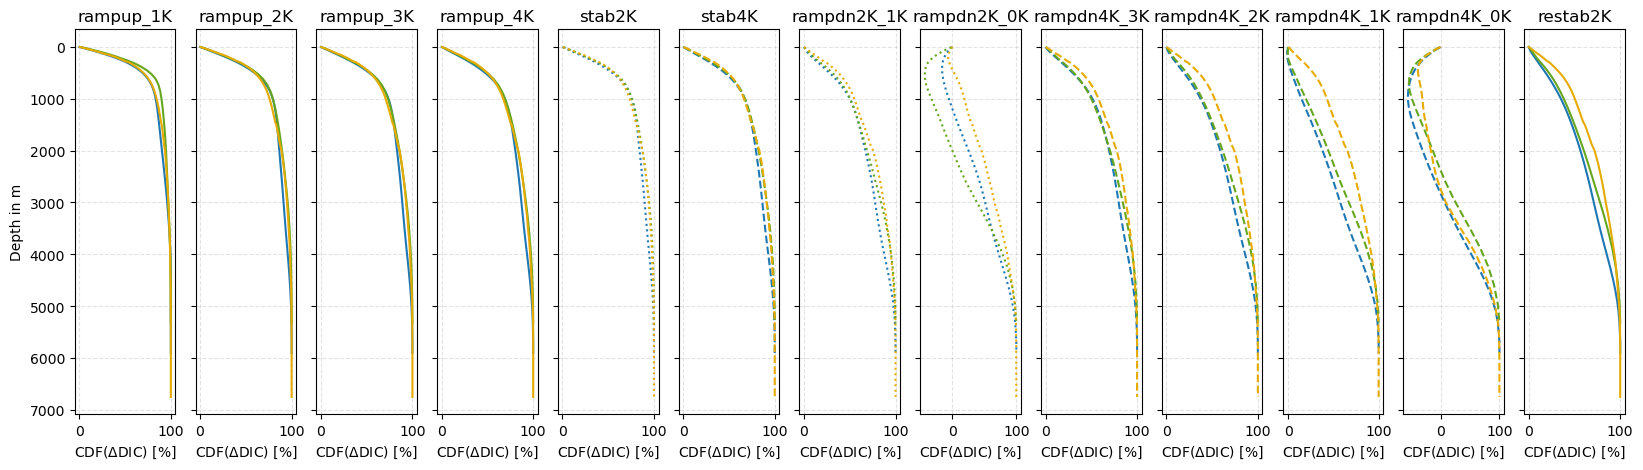

In [41]:
fig, ax = plt.subplots(1,len(time_slice_names)-1,figsize=(20,5),sharey=True)#,sharex=True)
for tdx,time_slice_name in enumerate(time_slice_names[1:]):

    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        
        ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
        vals = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral
        profile = vals
        profile = (profile).cumsum(zlev)/(profile).sum(zlev)*100
        #print((profile).sum(zlev).values)
        run = identify_run(time_slice_name)
        ax[tdx].plot(profile,profile[zlev],color=model_dict[model].color_id,linestyle=run_dict[run].linestyle_id)
        
    ax[tdx].grid(alpha=0.35,linestyle='--',zorder=-10)
    ax[tdx].set_title(time_slice_name)
    ax[tdx].set_xlabel(f'CDF($\Delta$DIC) [%]')

ax[0].invert_yaxis()
ax[0].set_ylabel('Depth in m')


## Plot at comparable GWL (1K)

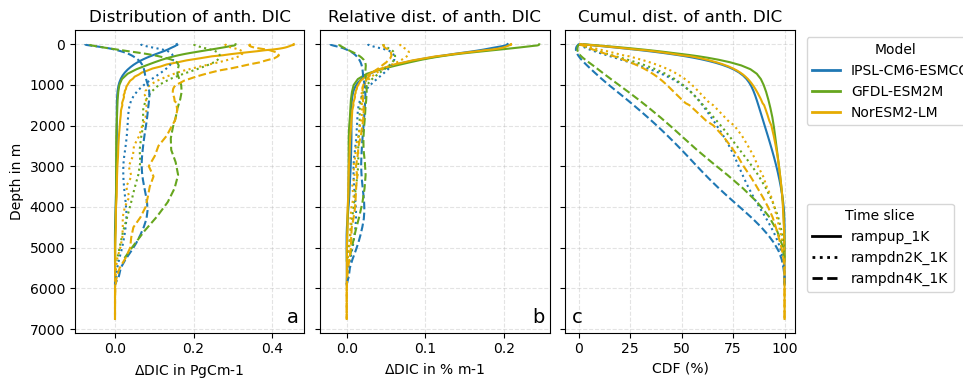

In [96]:
fig, ax = plt.subplots(1,3,figsize=(10,4),sharey=True)#,sharex=True)

for tdx,time_slice_name in enumerate(['rampup_1K','rampdn2K_1K','rampdn4K_1K']):

    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
        profile = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral / dzdict['dissic'][model][time_slice_name]['mean']
        profile = profile * 12.0107/1000/1000/1000/1000/1000
        run = identify_run(time_slice_name)
        ax[0].plot(profile,profile[zlev],color=model_dict[model].color_id,linestyle=run_dict[run].linestyle_id)
        
    ax[0].grid(alpha=0.35,linestyle='--',zorder=-10)
    ax[0].set_title('Distribution of anth. DIC')
    ax[0].set_xlabel(f'$\Delta$DIC in PgCm-1')

    
    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
        dz = dzdict['dissic'][model][time_slice_name]['mean']
        profile = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral / dz
        profile = profile * 12.0107/1000/1000/1000/1000/1000
        profile_sum = (profile*dz).sum(zlev)
        #print(profile_sum.values)
        profile = profile/profile_sum*100
        run = identify_run(time_slice_name)
        ax[1].plot(profile,profile[zlev],color=model_dict[model].color_id,linestyle=run_dict[run].linestyle_id)
        
    ax[1].grid(alpha=0.35,linestyle='--',zorder=-10)
    ax[1].set_title('Relative dist. of anth. DIC')
    ax[1].set_xlabel(f'$\Delta$DIC in % m-1')

    
    for model in models:
        if model == 'GFDL-ESM2M':
            zlev = 'olevel'
        else:
            zlev = 'lev'
        
        ref_profile = sdict['dissic'][model]['piC_at_start']['mean']
        vals = (sdict['dissic'][model][time_slice_name]['mean'] - ref_profile).dissic_global_integral
        profile = vals
        profile = (profile).cumsum(zlev)/(profile).sum(zlev)*100
        #print((profile).sum(zlev).values)
        run = identify_run(time_slice_name)
        ax[2].plot(profile,profile[zlev],color=model_dict[model].color_id,linestyle=run_dict[run].linestyle_id)
        
    ax[2].grid(alpha=0.35,linestyle='--',zorder=-10)
    #ax.set_title(time_slice_name)
    ax[2].set_xlabel(f'CDF (%)')
    ax[2].set_title('Cumul. dist. of anth. DIC')


ax[0].invert_yaxis()
ax[0].set_ylabel('Depth in m')
plt.tight_layout()
plt.subplots_adjust(right=0.8)


# Legend for model colours
model_handles = [
    Line2D([0], [0],
           color=model_dict[model].color_id,
           lw=2,
           label=model)
    for model in models
]

# Legend for time slices / line styles
timeslice_handles = []
for ts in ['rampup_1K', 'rampdn2K_1K', 'rampdn4K_1K']:
    run = identify_run(ts)
    timeslice_handles.append(
        Line2D([0], [0],
               color='k',
               lw=2,
               linestyle=run_dict[run].linestyle_id,
               label=ts)
    )

# Add both legends
leg1 = ax[2].legend(handles=model_handles,
                    title='Model',
                    loc='upper left',
                    bbox_to_anchor=(1.02, 1))

leg2 = ax[2].legend(handles=timeslice_handles,
                    title='Time slice',
                    loc='upper left',
                    bbox_to_anchor=(1.02, 0.45))

# Keep both legends
ax[2].add_artist(leg1)

labels = ['a','b','c']
for adx,axi in enumerate(ax):
    if adx != 2:
        xpos = 0.95
    else:
        xpos = 0.05
    axi.text(xpos,0.05,labels[adx],ha='center',va='center',transform=axi.transAxes,fontsize=14)

plot_dir = f'./../03_plots/vertical_profile_global_{stat}/{varia}/ref_first_year_of_rampup_win_21yr/{temporal_stat}'
os.makedirs(plot_dir,exist_ok = True)
plot_filename = f'{varia}_vert_profile_MMM_{temporal_stat}_ref_first_year_of_rampup_win21yr.png'
fig.savefig(f'{plot_dir}/{plot_filename}',dpi=300) # ,transparent=True

